In [1]:
import control as ct
from math import pi

In [2]:
s =ct.tf('s')

In [3]:
L=(1.66+1.37)*1E-3
R=2*0.01
Tf=L/R
Fs=10E3
Ts=1/Fs
print('L=',L,'R=',R)
print('Ts=',Ts)

L= 0.00303 R= 0.02
Ts= 0.0001


In [4]:
G1=1/(L*s+R)
print(G1)

<TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         1
  ----------------
  0.00303 s + 0.02


In [5]:
D=1/(1+1.5*Ts*s)
print(D)

<TransferFunction>: sys[11]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        1
  -------------
  0.00015 s + 1


In [6]:
plant=G1*D
print(plant)

<TransferFunction>: sys[12]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                  1
  ---------------------------------
  4.545e-07 s^2 + 0.003033 s + 0.02


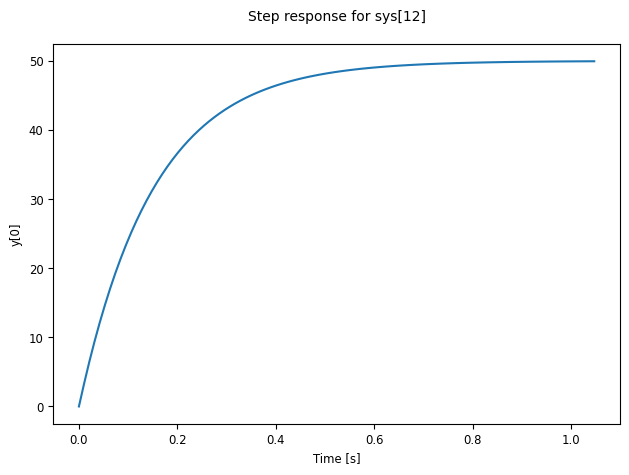

In [7]:
response = ct.step_response(plant)
cplt = response.plot()

In [8]:
Kp=2*L/(3*Ts)
print('Kp=',Kp)

Kp= 20.2


In [9]:
Ki=Kp/Tf
print('Ki=',Ki)

Ki= 133.33333333333334


In [10]:
PI=Kp+Ki/s
print(PI)

<TransferFunction>: sys[18]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  20.2 s + 133.3
  --------------
        s


In [11]:
Gopen=PI*plant
print(Gopen)

<TransferFunction>: sys[19]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             20.2 s + 133.3
  -------------------------------------
  4.545e-07 s^3 + 0.003033 s^2 + 0.02 s


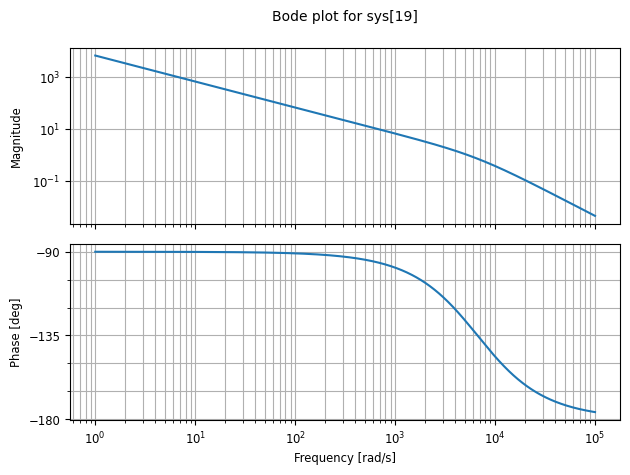

In [12]:
freqresp = ct.frequency_response(Gopen)
cplt = freqresp.plot()

In [13]:
G=Gopen/(1+Gopen)
print(G)

<TransferFunction>: sys[23]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                 9.181e-06 s^4 + 0.06133 s^3 + 0.8084 s^2 + 2.667 s
  ---------------------------------------------------------------------------------
  2.066e-13 s^6 + 2.757e-09 s^5 + 1.84e-05 s^4 + 0.06145 s^3 + 0.8088 s^2 + 2.667 s


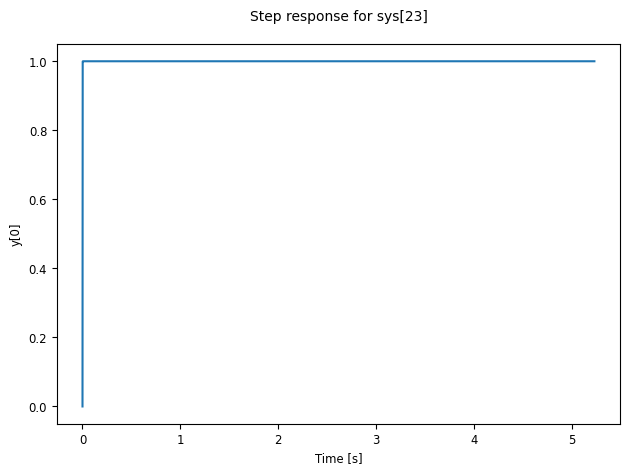

In [14]:
response = ct.step_response(G)
cplt = response.plot()

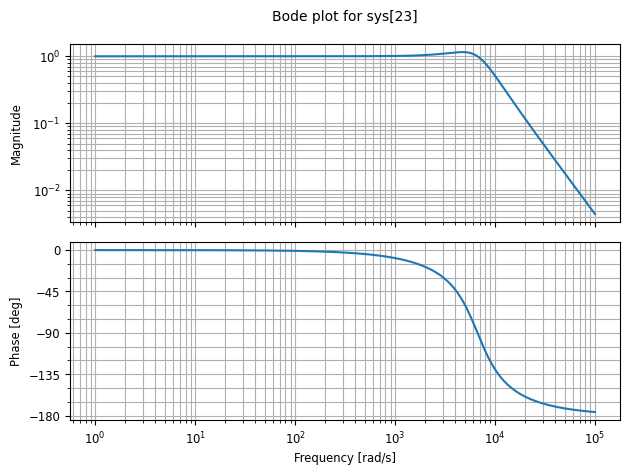

In [15]:
freqresp = ct.frequency_response(G)
cplt = freqresp.plot()

In [16]:
W=2*pi*Fs/10
Kp=2*0.707*W*L-R
Ki=W*W*L
print('Kp=',Kp)
print('Ki=',Ki)

Kp= 26.899804793786362
Ki= 119619.60534120303


In [17]:
C=Kp+Ki/s
print(C)

<TransferFunction>: sys[30]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  26.9 s + 1.196e+05
  ------------------
          s


In [18]:
Gc=C*G1/(1+C*G1)
print(Gc)

<TransferFunction>: sys[35]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          0.08151 s^3 + 363 s^2 + 2392 s
  ----------------------------------------------
  9.181e-06 s^4 + 0.08163 s^3 + 363 s^2 + 2392 s


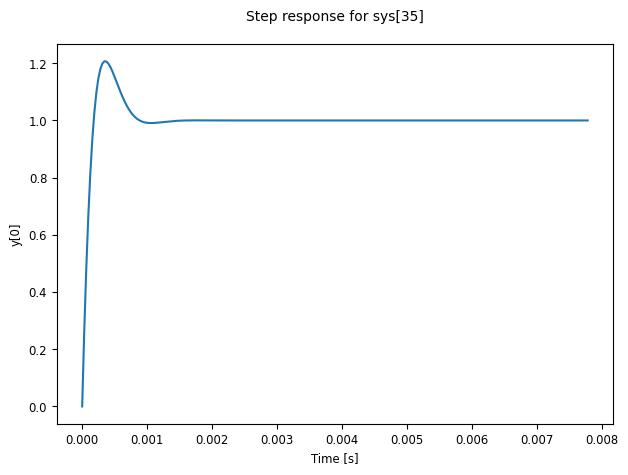

In [19]:
response = ct.step_response(Gc)
cplt = response.plot()